# **Esame del 10 settembre 2024**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti + 1 extra.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si consideri il seguente problema algebrico: data $A \in \mathbb{R}^{n\times n}$ e $b \in \mathbb{R}^n$ trovare $x\in \mathbb{R}^n$ tale che
$$
A x = b
$$
dove $A$ e $b$ sono dati da
$${A}=\left[\begin{array}{rrrrrrr}
9 & -3 & 1 &  &  & & \\
-3 & 9 & -3 & 1 &  & & \\
1 & -3 & 9 & -3 & 1 & & \\
& 1 & -3 & 9 & -3 & 1 &\\
& & 1 & -3 & 9 & -3 & 1 \\
& & & 1 & -3 & 9 & -3  \\
& & & & 1 & -3 & 9  \\
\end{array}\right]
\quad\quad {b}=\left[\begin{array}{c}7\\4\\5\\5\\5\\4\\7\end{array}\right].$$


#### **(1a) (2 punti) [T]**  

Uno schema iterativo per la soluzione di sistemi lineari si può scrivere nella seguente forma generale: dato $x^0 \in \mathbb{R}^n$ calcolo la soluzione tentativo al passo successivo $x^{k+1}\in \mathbb{R}^n$ come
$$
x^{k+1} = B x^{k} + g.
$$
Enunciare la condizione necessaria e sufficiente per la sua convergenza.

#### **(1b) (3 punti) [T]**  

Illustrare i casi particolari del metodo di Jacobi e di Gauss-Seidel per la risoluzione del problema precedente, enunciarne quindi le condizioni di convergenza (sufficienti e necessarie-e-sufficienti).

#### **(1c) (2 punti) [P]**  

Verificare che per il problema in considerazione le condizioni sopra enunciate siano soddisfatte (verificare una condizione a scelta per metodo), utilizzando le funzioni `Jacobi_Bc` e `GS_Bc` per costruire le matrici di iterazione. Per il calcolo degli autovalori si può usare la funzione `eigvals` del pacchetto `scipy.linalg`.

In [1]:
import numpy as np

from scipy.linalg import eigvals

from functions import Jacobi_Bc, GS_Bc

In [14]:
help(eigvals)

Help on function eigvals in module scipy.linalg._decomp:

eigvals(
    a,
    b=None,
    overwrite_a=False,
    check_finite=True,
    homogeneous_eigvals=False
)
    Compute eigenvalues from an ordinary or generalized eigenvalue problem.

    Find eigenvalues of a general matrix::

        a   vr[:,i] = w[i]        b   vr[:,i]

    The documentation is written assuming array arguments are of specified
    "core" shapes. However, array argument(s) of this function may have additional
    "batch" dimensions prepended to the core shape. In this case, the array is treated
    as a batch of lower-dimensional slices; see :ref:`linalg_batch` for details.
    Note that calls with zero-size batches are unsupported and will raise a ``ValueError``.

    Parameters
    ----------
    a : (M, M) array_like
        A complex or real matrix whose eigenvalues and eigenvectors
        will be computed.
    b : (M, M) array_like, optional
        Right-hand side matrix in a generalized eigenvalue prob

In [18]:
#costruzione A
n=7
A= -3*np.diag(np.ones(n-1), +1) +np.diag(np.ones(n-2),+2)
A=A+A.T + 9*np.diag(np.ones(n))
A

#costruzione b
b=[7, 4, 5, 5 ,5 , 4, 7]

#verifica per Jacobi
Bj, fj=Jacobi_Bc(A,b)
rho_Bj=np.max(np.abs(eigvals(Bj)))
if rho_Bj>1: 
    print("La CNS per Jacobi non è soddisfatta")
else:
    print("La CNS per Jacobi è soddisfatta")

#verifica per Gauss Seidel
Bgs, fgs= GS_Bc(A,b)
rho_Bgs=np.max(np.abs(eigvals(Bgs)))
if rho_Bgs>1: 
    print("La CNS per Gauss- Seidel non è soddisfatta")
else:
    print("La CNS per Gauss- Seidel è soddisfatta")


La CNS per Jacobi è soddisfatta
La CNS per Gauss- Seidel è soddisfatta


#### **(1d) (3 punti) [P+T]**

Sia $x^*\in \mathbb{R}^n$ soluzione di riferimento, calcolata come qui di seguito. Utilizzando la funzione `iterative_solve` risolvere il problema sia con il metodo di Jacobi che con il metodo di Gauss-Seidel. Calcolare l'errore relativo ottenuto rispetto a $x^*$ e il numero di iterazioni effettuate. Commentare i risultati ottenuti.

Si utilizzi una tolleranza relativa pari a $1e-6$ e un numero massimo di iterazioni pari a 100.

In [24]:
help(iterative_solve)

Help on function iterative_solve in module functions:

iterative_solve(A, b, x0, method, nmax, rtoll)
    Solve a linear system iteratively using the specified method.

    Parameters:
        A (numpy.ndarray): The coefficient matrix of the linear system.
        b (numpy.ndarray): The right-hand side vector of the linear system.
        x0 (numpy.ndarray): The initial guess for the solution vector.
        method (str): The iterative method to use (either "Jacobi" or "GS").
        nmax (int): The maximum number of iterations.
        rtoll (float): The relative tolerance for convergence.

    Returns:
        xiter (list): A list containing the iterates of the solution vector.



In [26]:
from functions import iterative_solve
b = np.array([7, 4, 5, 5 ,5 , 4, 7])

x_star = np.linalg.solve(A, b)

x0=np.zeros(n)

#risoluzione con Jacobi
x_j=iterative_solve(A, b, x0, method="Jacobi", nmax=100, rtoll=1e-6)
err_j=np.linalg.norm((x_j[-1] - x_star) / np.linalg.norm(x_star))
print(err_j)
print(len(x_j))

#risoluzione con Gauss Seidel
x_gs=iterative_solve(A, b, x0, method="GS", nmax=100, rtoll=1e-6)
err_gs=np.linalg.norm((x_gs[-1] - x_star) / np.linalg.norm(x_star))
print(err_gs)
print(len(x_gs))


3.206429167036422e-07
50
2.120279028385124e-07
13


# **Esercizio 2 (10 punti)**


Si consideri la seguente funzione $f$ definita nell'intervallo $I = [-\frac{3}{4}, \frac{3}{4}]$, estremi inclusi:

$$
f(x) = x \sin(2\pi x)^2
$$

#### **(2a) (1 punti) [P+T]**

Rappresentare graficamente la funzione $f$ e calcolare analiticamente i suoi zeri nell'intervallo $I$.

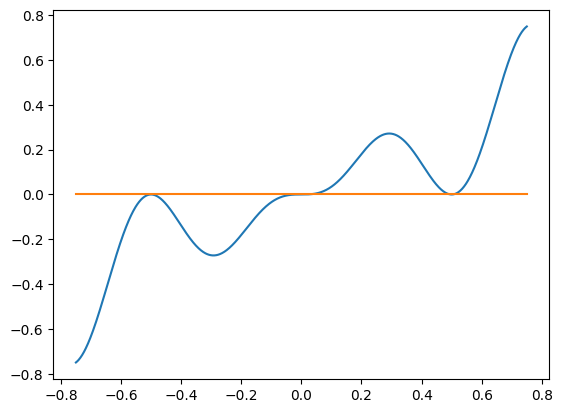

In [28]:
import numpy as np
import matplotlib.pyplot as plt

a=-3/4
b=3/4
f=lambda x: x*np.sin(2*np.pi*x)**2
x_grid=np.linspace(a,b, 1000)

plt.plot(x_grid, f(x_grid))
plt.plot(x_grid, np.zeros_like(x_grid))


#### **(2b) (3 punti) [T]**

Derivare il metodo di Newton e Newton modificato per la ricerca degli zeri di una funzione, specificandone le proprietà di convergenza.

In [29]:
#Metodo di Newton:
#preso un xk, scriviamo l'espansione in serie di Taylor di f centrata in xk: f(x)=f(xk)+(x-xk)*f'(xk)+...
#Se ci fermiamo al 1 ordine si tratta di una retta: la valuto in xk+1 ponendo che tale retta si annulla appunto in xk+1:
#f(xk+1)=f(xk)+(xk+1-xk)*f'(xk)=0--> xk+1=xk-f(xk)/f'(xk) e poi ripeto per k successivi

#il metodo di Newton converge quadraticamente se e solo se f è di classe C1 e se ha molteplicità algebrica pari a 1.  Se invece consideriamo
#una f con molteplicità algebrica maggiore di 1 il metodo non convergerà quadraticamente ma solo linearmente.
#per recuperare la convergenza quadratica si sfrutta quindi il metodo di newton modificato:
#xk+1=xk-m*f(xk)/f'(xk)

#### **(2c) (4 punti) [P]**

Date le proprietà di convergenza sopra descritte, e le proprietà degli zeri, calcolare questi ultimi utilizzahndo la funzione `newton`. Si utilizzino i punti di partenza dati da $x_0 = \alpha + \epsilon$, dove $\alpha$ è lo zero esatto e $\epsilon = 0.1$.

**Attenzione** si utilizzino in maniera *opportuna* il metodo di Newton o di Newton modificato per ottenere la più rapida convergenza.

In [31]:
from functions import newton
help(newton)

Help on function newton in module functions:

newton(f, df, x0, nmax=100, tol=1e-06, m=1)
    Approximates the root of a function using Newton's method.

    Parameters:
        f (callable): The function for which to find the root.
        df (callable): The derivative of the function.
        x0 (numpy.ndarray): The initial guess for the root.
        nmax (int): The maximum number of iterations (default: 100).
        tol (float): The tolerance for convergence (default: 1e-6).
        m (int): The multiplicative factor (default: 1).

    Returns:
        xvect (numpy.ndarray): An array containing the sequence of approximations to the root.



In [ ]:
#per avere la convergenza più veloce dobbiamo conoscere la molteplicità algebrica della funzione

#dal grafico notiamo che il punto alfa=-0,5 ha molteplicità 2 (punto di massimo), alfa=0 ha molt 3 (flesso a tangente orizzontale) e alfa=0,5 ha 
# molt =2 (punto di minimo). Quindi dobbiamo usare per tutti e tre i casi il metodo di newton modificato


In [38]:
f=lambda x: x*np.sin(2*np.pi*x)**2
df=lambda x: np.sin(2*np.pi*x)**2 + 4*np.pi*x*np.sin(2*np.pi*x)*np.cos(2*np.pi*x)

x_1=newton(f,df,-0.5+0.1, 1e-16, 2)
print(x_1[-1], len(x_1))

x_2=newton(f,df,0.1, 1e-16, 3)
print(x_2[-1], len(x_2))

x_3=newton(f,df,0.5+0.1, 1e-16, 2)
print(x_3[-1], len(x_3))



-0.46758526157379193 1
0.06336476374234722 1
0.547265149524017 1


#### **(2d) (2 punti) [P+T]**

Identificare per quale zero di $f$ è possibile applicare il metodo di bisezione, quindi usare la funzione `bisez` per calcolarlo. Si commenti il risultato ottenuto.

In [39]:
#possiamo applicare il metodo di bisezione solo per il secondo punto di zero, perché deve valere: f(a)*f(b)<0


In [41]:
from functions import bisez
help(bisez)

Help on function bisez in module functions:

bisez(f, a, b, tol=1e-06)
    Perform the bisection method to find the zeros of a function within a given interval.

    Parameters:
        f (callable): The function for which to find the zeros.
        a (float): The left endpoint of the interval.
        b (float): The right endpoint of the interval.
        tol (float, optional): The tolerance for the convergence of the method. Defaults to
            1e-6.

    Returns:
    x_vect (numpy.ndarray): An array containing the intermediate values of x during the
        bisection method.

    Raises:
        RuntimeError: If the interval [a,b] is not a bracket (i.e., f(a) * f(b) >= 0).



In [43]:
a=-0.5
b=0.5
x2_bisez=bisez(f,a, b, 1e-16)
print(x2_bisez[-1], len(x2_bisez))

x è uno zero della funzione
0.0 1


# **Esercizio 3 (10+1 punti)**




Si consideri il seguente problema differenziale tempo dipendente sul dominio $\Omega_T=(a,b)\times[0,T)$

$$
\begin{cases}
\partial_t u - \partial_{xx}u = f\quad \mathrm{in}\,\Omega_T\\
u(x,0) = 0 \quad \mathrm{in}\,(a,b)\\
u(a,t) = 0 \quad \mathrm{in}\,[0,T)\\
u(b,t) = 0 \quad \mathrm{in}\,[0,T),
\end{cases}
$$

con $a=0$, $b=1$, $f=1$ e $T=1$.

#### **(3a) (4 punti) [T]**

Introdurre per il problema in esame la discretizzazione in spazio con il metodo degli elementi finiti, e in tempo con il generico theta metodo.

#### **(3b) (2 punti) [P]**

Completare la funzione `heatsolve` fornita assemblando, all'interno del ciclo temporale, la matrice ed il termine noto per un generico theta.

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from fem import install
from fem import xtplot

install()

ModuleNotFoundError: No module named 'fenics'

In [45]:
from fem import Line, generate_mesh, FEspace, assemble, interpolate, deriv, dx, ds, DirichletBC, applyBCs, dof2fun, fun2dof, dofs, plot

def heatSolve(D,f,u0,L,h,T,dt,theta):
  """"
  Input:
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     L      (float)                  Lunghezza dell'intervallo spaziale.
     h      (float)                  Passo della griglia spaziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    V                               spazio elementi finiti
    u     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    t      (numpy.ndarray)-> vector Griglia temporale.
  """""
  # costruisco il dominio
  domain = Line(0, L)
  # costruisco la mesh
  mesh = generate_mesh(domain, stepsize = h)
  # costruisco lo spazio FEM di grado 1
  V = FEspace(mesh, 1)

  # costruisco la griglia temporale
  nt = np.ceil(T/dt)+1
  t = np.zeros(int(nt))

  # initializzo la soluzione
  u = np.zeros((dofs(V).size, int(nt)))

  # definisco la condizione iniziale
  u0h = fun2dof(interpolate(u0,V))
  u[:, 0] = u0h

  # matrice di massa
  def m(u, v):
    return u*v*dx
  # assemblaggio matrice di massa
  M = assemble(m, V)

  # matrice di diffusione
  def a(u,v):
    return deriv(u)*deriv(v)*dx
  # assemblaggio matrice di diffusione
  A = D*assemble(a,V)

  # ciclo temporale
  for n in range(int(nt)-1):
    # costruzioni termini noti al tempo dt e dt+1
    t_old = n*dt
    t_new = (n+1)*dt

    fold = lambda x: f(x,t_old)
    fnew = lambda x: f(x,t_new)

    fold_h = interpolate(fold, V)
    def lold(v):
      return fold_h*v*dx
    Fold = assemble(lold, V)

    fnew_h = interpolate(fnew, V)
    def lnew(v):
      return fnew_h*v*dx
    Fnew = assemble(lnew, V)

    # condizioni al bordo omogenee di tipo dirichlet
    def isLeftNode(x):
      return x < 1e-12

    def isRightNode(x):
      return x > L - 1e-12

    dbc1 = DirichletBC(isLeftNode,  0.0)
    dbc2 = DirichletBC(isRightNode, 0.0)

    A = applyBCs(A, V, dbc1, dbc2)
    M = applyBCs(M, V, dbc1, dbc2)
    Fold = applyBCs(Fold, V, dbc1, dbc2)
    Fnew = applyBCs(Fnew, V, dbc1, dbc2)

    # TODO: assemblare la matrice e il termine noto per il theta metodo
    B =M/dt+theta*A
    b =(M/dt+(1-theta)*A)@ u[:,n] +theta * Fnew +(1-theta)* Fold

    from scipy.sparse.linalg import spsolve

    u[:,n+1] = spsolve(B, b)
    t[n+1] = t_new

  return V,u,t


ModuleNotFoundError: No module named 'fenics'

#### **(3c) (2 punti) [P+T]**

Risolvere il problema con il metodo di Eulero Implicito, ponendo $h=0.1$ e $dt = 0.01$. Rappresentare e commentare il risultato ottenuto.

In [46]:
D=1
f=1
u0=lambda x: 0+0*x
L=1
T=1
theta=1
h=0.1
dt=0.01
V,u,t=heat_solve(D,f,u0,L,h,T,dt,theta)

xtplot(V,u, t, 'fade')



NameError: name 'heat_solve' is not defined

#### **(3d) (1 punto) [P]**

Rappresentare l'andamento della soluzione in $x=0.5$ al variare del tempo.

#### **(3e) (1 punto) [P+T]**

Mantenendo gli stessi parametri di discretizzazione, ora risolvere il problema con il metodo di Eulero Esplicito e rappresentare il risultato ottenuto. Commentare il risultato ottenuto alla luce della **teoria** e proporre una strategia migliorativa.

#### **(3f) (1 punto extra) [T]**

Calcolare analiticamente la soluzione stazionaria dell'equazione.
